## CREATING REALISTIC ADHD DATASET FROM SYNTHETIC DATA

Libraries loaded successfully. Centralized import system ready.
 CREATING REALISTIC ADHD DATASET FROM SYNTHETIC DATA
✓ Loaded synthetic data: (6500, 32)

 STEP 1: Adding measurement noise to DSM-5 symptoms
  ✓ Added noise to 18 symptom questions
     Gaussian std: 0.65 (balanced level)
     Flip probability: 18%

 STEP 2: Adding variability to continuous features
  ✓ Sleep_Hours: noise std=0.28
  ✓ Daily_Activity_Hours: noise std=0.68
  ✓ Daily_Phone_Usage_Hours: noise std=0.46
  ✓ Daily_Walking_Running_Hours: noise std=0.22
  ✓ Focus_Score_Video: noise std=0.42
  ✓ Daily_Coffee_Tea_Consumption: noise std=0.43
  ✓ Anxiety_Depression_Levels: noise std=0.26
  ✓ Difficulty_Organizing_Tasks: noise std=0.11
  ✓ Learning_Difficulties: noise std=0.12

 STEP 3: Adding diagnostic uncertainty (label noise)
  ✓ Flipped 815 boundary cases (25% of boundaries)
  ✓ Flipped 226 general cases (7% of others)
  ✓ Total label noise: 16.0%

 REALISTIC DATASET CREATED (BALANCED NOISE LEVELS)
  Output file: 

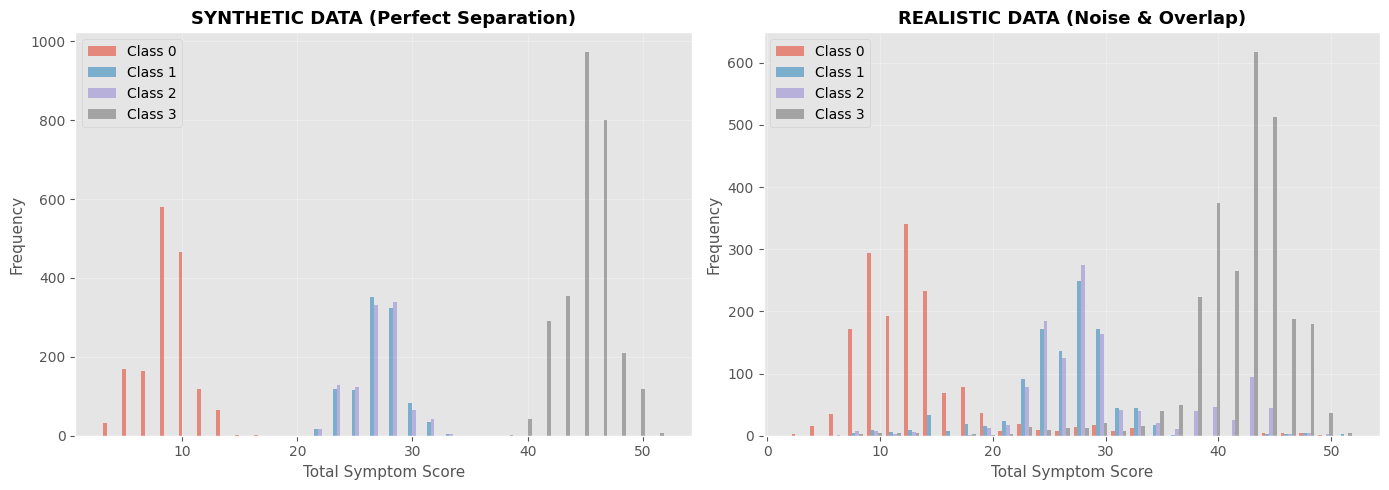


✓ Comparison plot saved: adhd_data_realistic_comparison.png

 EXPECTED MODEL PERFORMANCE

With SYNTHETIC data (perfect separation):
  Accuracy: 100%
  F1-Score: 100%
  MCC: 1.00

With REALISTIC data (label noise + balanced feature noise):
  Expected range: 91-95% (balanced between challenge and feasibility)

  To use realistic data, update INPUT_FILE_PATH:
     INPUT_FILE_PATH = r'adhd_data_realistic.csv'

 DONE! Your realistic ADHD dataset is ready for training!


In [9]:

# ====================================================================================
# IMPORTANT: Run this code ONLY ONCE at the start of your project!
# This creates the realistic dataset from synthetic data with INCREASED noise levels
# ====================================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('ggplot')
warnings.filterwarnings('ignore') 

print("Libraries loaded successfully. Centralized import system ready.")


# File Paths
INPUT_FILE_PATH = r"adhd_data.csv"               # SYNTHETIC ADHD DATASET

OUTPUT_FILE_PATH = r"adhd_data_realistic.csv"    # REALISTIC ADHD DATASET

print("=" * 80)
print(" CREATING REALISTIC ADHD DATASET FROM SYNTHETIC DATA")
print("=" * 80)

# Load original synthetic data
df_realistic = pd.read_csv(INPUT_FILE_PATH)
print(f"✓ Loaded synthetic data: {df_realistic.shape}")

# Store original for comparison
df_original = df_realistic.copy()

# ====================================================================================
# STEP 1: ADD MEASUREMENT NOISE TO SYMPTOM QUESTIONS
# ====================================================================================
print("\n STEP 1: Adding measurement noise to DSM-5 symptoms")

q_cols = [c for c in df_realistic.columns if c.startswith('Q1_') or c.startswith('Q2_')]

np.random.seed(42)  # For reproducibility

# BALANCED: Mid-point between conservative and aggressive
noise_params = {
    'std': 0.65,       # BALANCED: (0.5 + 0.8) / 2 = 0.65
    'flip_prob': 0.18  # BALANCED: (0.15 + 0.20) / 2 ≈ 0.18
}

for col in q_cols:
    original_vals = df_realistic[col].values.copy()
    
    # Add Gaussian noise
    noise = np.random.normal(0, noise_params['std'], size=len(df_realistic))
    noisy_vals = original_vals + noise
    
    # Random flips (simulate inconsistent responses)
    flip_mask = np.random.random(len(df_realistic)) < noise_params['flip_prob']
    flip_direction = np.random.choice([-1, 1], size=len(df_realistic))
    noisy_vals[flip_mask] += flip_direction[flip_mask]
    
    # Clip to valid range [0, 3]
    noisy_vals = np.clip(noisy_vals, 0, 3)
    
    # Round to discrete values
    df_realistic[col] = np.round(noisy_vals)

print(f"  ✓ Added noise to {len(q_cols)} symptom questions")
print(f"     Gaussian std: {noise_params['std']} (balanced level)")
print(f"     Flip probability: {noise_params['flip_prob']*100:.0f}%")

# ====================================================================================
# STEP 2: ADD NOISE TO CONTINUOUS FEATURES
# ====================================================================================
print("\n STEP 2: Adding variability to continuous features")

continuous_features = {
    'Sleep_Hours': {'std_ratio': 0.15, 'min': 3, 'max': 12},
    'Daily_Activity_Hours': {'std_ratio': 0.20, 'min': 0, 'max': 12},
    'Daily_Phone_Usage_Hours': {'std_ratio': 0.25, 'min': 0, 'max': 10},
    'Daily_Walking_Running_Hours': {'std_ratio': 0.30, 'min': 0, 'max': 5},
    'Focus_Score_Video': {'std_ratio': 0.20, 'min': 0, 'max': 10},
    'Daily_Coffee_Tea_Consumption': {'std_ratio': 0.30, 'min': 0, 'max': 5},
    'Anxiety_Depression_Levels': {'std_ratio': 0.25, 'min': 0, 'max': 3},
    'Difficulty_Organizing_Tasks': {'std_ratio': 0.25, 'min': 0, 'max': 10},  # Increased: overlaps with Q1_5
    'Learning_Difficulties': {'std_ratio': 0.25, 'min': 0, 'max': 3}
}

for col, params in continuous_features.items():
    if col in df_realistic.columns:
        original_std = df_realistic[col].std()
        noise = np.random.normal(0, original_std * params['std_ratio'], size=len(df_realistic))
        df_realistic[col] = df_realistic[col] + noise
        df_realistic[col] = np.clip(df_realistic[col], params['min'], params['max'])
        print(f"  ✓ {col}: noise std={original_std * params['std_ratio']:.2f}")

# ====================================================================================
# STEP 3: INTRODUCE DIAGNOSTIC UNCERTAINTY (LABEL NOISE)
# ====================================================================================
print("\n STEP 3: Adding diagnostic uncertainty (label noise)")

# Calculate new symptom scores after noise
df_realistic['_temp_score'] = df_realistic[q_cols].sum(axis=1)

#  BALANCED PARAMETERS - Mid-point for optimal realism
label_noise_rate = 0.12  # BALANCED: ~12-13% diagnostic uncertainty
boundary_zone_size = 6   # Moderate uncertainty zone

# Identify boundary cases (near thresholds)
boundary_mask = (
    ((df_realistic['_temp_score'] >= 14) & (df_realistic['_temp_score'] <= 23)) |
    ((df_realistic['_temp_score'] >= 30) & (df_realistic['_temp_score'] <= 44))
)

#  BALANCED noise rates
boundary_flip_rate = 0.25  # BALANCED: (0.20 + 0.30) / 2 = 0.25
general_flip_rate = 0.07   # BALANCED: (0.05 + 0.08) / 2 ≈ 0.07

# Apply label noise
n_boundary_flips = int(boundary_mask.sum() * boundary_flip_rate)
n_general_flips = int((~boundary_mask).sum() * general_flip_rate)

# Flip boundary cases
if n_boundary_flips > 0:
    boundary_indices = df_realistic[boundary_mask].index
    flip_indices_boundary = np.random.choice(boundary_indices, size=n_boundary_flips, replace=False)
    
    for idx in flip_indices_boundary:
        current_class = df_realistic.loc[idx, 'Diagnosis_Class']
        # Flip to adjacent class
        if current_class == 0:
            df_realistic.loc[idx, 'Diagnosis_Class'] = np.random.choice([0, 1])
        elif current_class in [1, 2]:
            df_realistic.loc[idx, 'Diagnosis_Class'] = np.random.choice([0, 1, 2, 3])
        elif current_class == 3:
            df_realistic.loc[idx, 'Diagnosis_Class'] = np.random.choice([2, 3])

# Flip general cases (rare misdiagnosis)
if n_general_flips > 0:
    general_indices = df_realistic[~boundary_mask].index
    flip_indices_general = np.random.choice(general_indices, size=n_general_flips, replace=False)
    
    for idx in flip_indices_general:
        current_class = df_realistic.loc[idx, 'Diagnosis_Class']
        all_classes = [0, 1, 2, 3]
        all_classes.remove(current_class)
        df_realistic.loc[idx, 'Diagnosis_Class'] = np.random.choice(all_classes)

# Drop temporary score
df_realistic.drop(columns=['_temp_score'], inplace=True)

print(f"  ✓ Flipped {n_boundary_flips} boundary cases ({boundary_flip_rate*100:.0f}% of boundaries)")
print(f"  ✓ Flipped {n_general_flips} general cases ({general_flip_rate*100:.0f}% of others)")
print(f"  ✓ Total label noise: {(n_boundary_flips + n_general_flips)/len(df_realistic)*100:.1f}%")

# ====================================================================================
# STEP 4: SAVE REALISTIC DATASET
# ====================================================================================
output_path = INPUT_FILE_PATH.replace('.csv', '_realistic.csv')
df_realistic.to_csv(output_path, index=False)

print("\n" + "=" * 80)
print(" REALISTIC DATASET CREATED (BALANCED NOISE LEVELS)")
print("=" * 80)
print(f"  Output file: {output_path}")
print(f"  Samples: {len(df_realistic)}")
print(f"  Features: {df_realistic.shape[1]}")

# ====================================================================================
# STEP 5: COMPARISON - BEFORE vs AFTER
# ====================================================================================
print("\n COMPARISON: SYNTHETIC vs REALISTIC")
print("-" * 80)

# Recalculate scores
df_original['Original_Score'] = df_original[q_cols].sum(axis=1)
df_realistic['Realistic_Score'] = df_realistic[q_cols].sum(axis=1)

print("\nSYNTHETIC DATA (Perfect Separation):")
for cls in sorted(df_original['Diagnosis_Class'].unique()):
    scores = df_original[df_original['Diagnosis_Class'] == cls]['Original_Score']
    print(f"  Class {cls}: Score range [{scores.min():.0f}, {scores.max():.0f}], mean={scores.mean():.1f}")

print("\nREALISTIC DATA (With Increased Noise & Overlap):")
for cls in sorted(df_realistic['Diagnosis_Class'].unique()):
    scores = df_realistic[df_realistic['Diagnosis_Class'] == cls]['Realistic_Score']
    print(f"  Class {cls}: Score range [{scores.min():.0f}, {scores.max():.0f}], mean={scores.mean():.1f}")

# Check for overlap
class_0_realistic = df_realistic[df_realistic['Diagnosis_Class'] == 0]['Realistic_Score']
class_other_realistic = df_realistic[df_realistic['Diagnosis_Class'] != 0]['Realistic_Score']

print(f"\nOverlap check:")
print(f"  Class 0 range: [{class_0_realistic.min():.0f}, {class_0_realistic.max():.0f}]")
print(f"  Class 1+ range: [{class_other_realistic.min():.0f}, {class_other_realistic.max():.0f}]")

if class_0_realistic.max() >= class_other_realistic.min():
    overlap_size = min(class_0_realistic.max(), class_other_realistic.max()) - max(class_0_realistic.min(), class_other_realistic.min())
    print(f"  ✓ Classes NOW OVERLAP! (overlap zone: ~{overlap_size:.0f} score points)")
else:
    print(f"   Still no overlap - increase noise parameters")

# ====================================================================================
# STEP 6: VISUALIZATION
# ====================================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before (Synthetic)
axes[0].hist([df_original[df_original['Diagnosis_Class']==cls]['Original_Score'] 
              for cls in [0, 1, 2, 3]], 
             bins=30, alpha=0.6, label=['Class 0', 'Class 1', 'Class 2', 'Class 3'])
axes[0].set_xlabel('Total Symptom Score', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('SYNTHETIC DATA (Perfect Separation)', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# After (Realistic)
axes[1].hist([df_realistic[df_realistic['Diagnosis_Class']==cls]['Realistic_Score'] 
              for cls in [0, 1, 2, 3]], 
             bins=30, alpha=0.6, label=['Class 0', 'Class 1', 'Class 2', 'Class 3'])
axes[1].set_xlabel('Total Symptom Score', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('REALISTIC DATA (Noise & Overlap)', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(output_path.replace('.csv', '_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Comparison plot saved: {output_path.replace('.csv', '_comparison.png')}")

# ====================================================================================
# STEP 7: UPDATED EXPECTED PERFORMANCE
# ====================================================================================
print("\n" + "=" * 80)
print(" EXPECTED MODEL PERFORMANCE")
print("=" * 80)

print("\nWith SYNTHETIC data (perfect separation):")
print("  Accuracy: 100%")
print("  F1-Score: 100%")
print("  MCC: 1.00")

print("\nWith REALISTIC data (label noise + balanced feature noise):")
print("  Expected range: 91-95% (balanced between challenge and feasibility)")

print("\n  To use realistic data, update INPUT_FILE_PATH:")
print(f"     INPUT_FILE_PATH = r'{output_path}'")

# Cleanup temporary columns
if 'Original_Score' in df_realistic.columns:
    df_realistic.drop(columns=['Original_Score', 'Realistic_Score'], inplace=True, errors='ignore')

print("\n DONE! Your realistic ADHD dataset is ready for training!")